In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score,
)
print("All imports successful.")


All imports successful.


## Task 1 – House Price Prediction (Linear Regression)



### 1.1 · Generate & Inspect Dataset

In [41]:
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 300
neighbourhoods    = ['Downtown', 'Suburbs', 'Rural']
neighbourhood_col = np.random.choice(neighbourhoods, n)
sqft      = np.random.randint(600, 4000, n)
bedrooms  = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
house_age = np.random.randint(1, 50, n)

nbr_effect = {'Downtown': 80000, 'Suburbs': 40000, 'Rural': 0}
price = (
    sqft * 150 + bedrooms * 10_000 + bathrooms * 8_000
    - house_age * 1_000
    + np.array([nbr_effect[nb] for nb in neighbourhood_col])
    + np.random.normal(0, 20_000, n)
)

df1 = pd.DataFrame({
    'sqft': sqft, 'bedrooms': bedrooms, 'bathrooms': bathrooms,
    'house_age': house_age, 'neighbourhood': neighbourhood_col, 'price': price,
})

df1.loc[np.random.choice(df1.index, 10, replace=False), 'sqft']          = np.nan
df1.loc[np.random.choice(df1.index,  5, replace=False), 'house_age']     = np.nan
df1.loc[np.random.choice(df1.index,  3, replace=False), 'neighbourhood'] = np.nan

print(f"Shape: {df1.shape}")
print(f"Missing values per column:\n{df1.isnull().sum().to_string()}")
df1.head(8)


Shape: (300, 6)
Missing values per column:
sqft             10
bedrooms          0
bathrooms         0
house_age         5
neighbourhood     3
price             0


,sqft,bedrooms,bathrooms,house_age,neighbourhood,price
0,3834.0,5,1,40.0,Rural,595169.555306
1,1556.0,4,3,15.0,Downtown,351711.866280
2,2304.0,1,3,21.0,Rural,319550.262540
3,760.0,5,3,47.0,Rural,135410.018684
4,2203.0,1,2,9.0,Downtown,434600.524877
5,3448.0,3,2,9.0,Downtown,622454.611645
6,997.0,1,2,10.0,Rural,161694.404255
7,1900.0,1,3,26.0,Suburbs,329919.265681


### 1.2 · Clean & Encode Categorical Variable

In [22]:
df1['sqft']          = df1['sqft'].fillna(df1['sqft'].median())
df1['house_age']     = df1['house_age'].fillna(df1['house_age'].median())
df1['neighbourhood'] = df1['neighbourhood'].fillna(df1['neighbourhood'].mode()[0])

le1 = LabelEncoder()
df1['neighbourhood_enc'] = le1.fit_transform(df1['neighbourhood'])

print("Missing values after cleaning:", df1.isnull().sum().sum())
print(f"Neighbourhood encoding: {dict(zip(le1.classes_, le1.transform(le1.classes_)))}")


Missing values after cleaning: 0
Neighbourhood encoding: {'Downtown': np.int64(0), 'Rural': np.int64(1), 'Suburbs': np.int64(2)}


### 1.3 · Feature Selection (Correlation with Price)

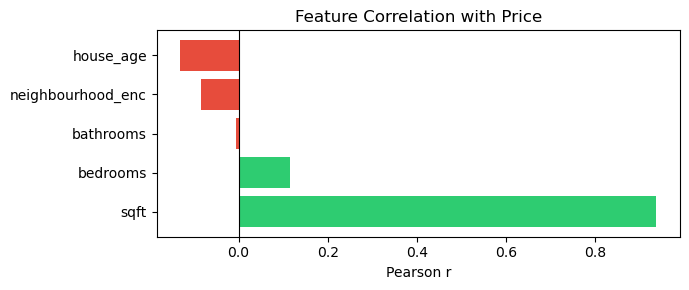

sqft                 0.937320
bedrooms             0.114277
bathrooms           -0.005473
neighbourhood_enc   -0.083416
house_age           -0.130631


In [23]:
features1 = ['sqft', 'bedrooms', 'bathrooms', 'house_age', 'neighbourhood_enc']
corr = df1[features1 + ['price']].corr()['price'].drop('price').sort_values(ascending=False)

colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in corr]
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(corr.index, corr.values, color=colors_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Price')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()
print(corr.to_string())


### 1.4 · Train Linear Regression Model

In [24]:
X1 = df1[features1]
y1 = df1['price']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)
y1_pred = lr1.predict(X1_test)

print(f"R²   : {r2_score(y1_test, y1_pred):.4f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(y1_test, y1_pred)):,.2f}")
print("\nModel Coefficients:")
for f, c in zip(features1, lr1.coef_):
    print(f"  {f:25s}: {c:>12,.2f}")
print(f"  {'Intercept':25s}: {lr1.intercept_:>12,.2f}")


R²   : 0.9527
RMSE : $33,614.38

Model Coefficients:
  sqft                     :       149.89
  bedrooms                 :    13,934.99
  bathrooms                :     7,770.10
  house_age                :    -1,258.27
  neighbourhood_enc        :   -22,116.62
  Intercept                :    58,831.78


### 1.5 · Evaluate – Actual vs Predicted Plot

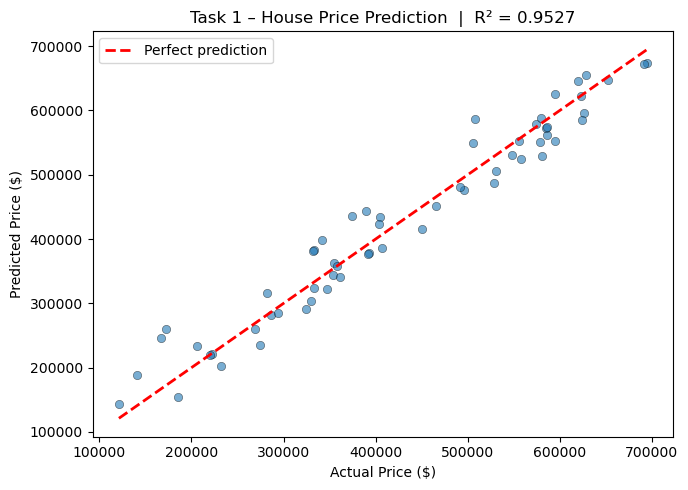

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y1_test, y1_pred, alpha=0.6, edgecolors='k', linewidths=0.4)
lims = [y1_test.min(), y1_test.max()]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title(f'Task 1 – House Price Prediction  |  R² = {r2_score(y1_test, y1_pred):.4f}')
ax.legend()
plt.tight_layout()
plt.show()


### 1.6 · Predict Price of a New House

In [26]:
new_house = pd.DataFrame([{
    'sqft': 1800, 'bedrooms': 3, 'bathrooms': 2,
    'house_age': 10, 'neighbourhood_enc': le1.transform(['Suburbs'])[0]
}])

predicted_price = lr1.predict(new_house)[0]
print("New house features:")
print(new_house.to_string(index=False))
print(f"\nPredicted Price: ${predicted_price:,.2f}")


New house features:
 sqft  bedrooms  bathrooms  house_age  neighbourhood_enc
 1800         3          2         10                  2

Predicted Price: $329,159.51


## Task 2 – Spam Email Classifier (Logistic Regression + SVM)


### 2.1 · Generate Dataset

In [27]:
np.random.seed(0)
spam_n, ham_n = 200, 300

spam2 = pd.DataFrame({
    'word_freq_free'    : np.random.uniform(0.3, 1.0, spam_n),
    'word_freq_money'   : np.random.uniform(0.2, 0.9, spam_n),
    'word_freq_click'   : np.random.uniform(0.3, 1.0, spam_n),
    'email_length'      : np.random.randint(50, 300, spam_n),
    'num_hyperlinks'    : np.random.randint(3, 15, spam_n),
    'suspicious_sender' : np.random.choice([0, 1], spam_n, p=[0.2, 0.8]),
    'label': 1
})
ham2 = pd.DataFrame({
    'word_freq_free'    : np.random.uniform(0.0, 0.2, ham_n),
    'word_freq_money'   : np.random.uniform(0.0, 0.15, ham_n),
    'word_freq_click'   : np.random.uniform(0.0, 0.2, ham_n),
    'email_length'      : np.random.randint(100, 800, ham_n),
    'num_hyperlinks'    : np.random.randint(0, 4, ham_n),
    'suspicious_sender' : np.random.choice([0, 1], ham_n, p=[0.9, 0.1]),
    'label': 0
})

df2 = pd.concat([spam2, ham2], ignore_index=True).sample(frac=1, random_state=1).reset_index(drop=True)
print(f"Shape: {df2.shape}")
print(f"Class balance:\n{df2['label'].value_counts().rename({0:'Ham',1:'Spam'}).to_string()}")
df2.head(6)


Shape: (500, 7)
Class balance:
label
Ham     300
Spam    200


,word_freq_free,word_freq_money,word_freq_click,email_length,num_hyperlinks,suspicious_sender,label
0,0.036295,0.046323,0.152787,579,0,0,0
1,0.055834,0.086271,0.126588,227,1,0,0
2,0.390248,0.328296,0.989844,87,6,1,1
3,0.367971,0.610487,0.513128,289,4,1,1
4,0.106465,0.104524,0.076090,732,3,0,0
5,0.084971,0.112707,0.133264,312,0,0,0


### 2.2 · Preprocess & Split

In [28]:
X2 = df2.drop('label', axis=1)
y2 = df2['label']
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
sc2 = StandardScaler()
X2_tr_sc = sc2.fit_transform(X2_train)
X2_te_sc = sc2.transform(X2_test)
print(f"Train: {X2_tr_sc.shape}  |  Test: {X2_te_sc.shape}")


Train: (400, 6)  |  Test: (100, 6)


### 2.3 · Train & Evaluate – Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_tr_sc, y2_train)
y2_lr = lr2.predict(X2_te_sc)

print(f"Logistic Regression Accuracy: {accuracy_score(y2_test, y2_lr):.4f}\n")
print(classification_report(y2_test, y2_lr, target_names=['Ham','Spam']))


Logistic Regression Accuracy: 1.0000

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00        60
        Spam       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### 2.4 · Train & Evaluate – SVM (RBF Kernel)

In [30]:
from sklearn.svm import SVC

svm2 = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm2.fit(X2_tr_sc, y2_train)
y2_svm = svm2.predict(X2_te_sc)

print(f"SVM Accuracy: {accuracy_score(y2_test, y2_svm):.4f}\n")
print(classification_report(y2_test, y2_svm, target_names=['Ham','Spam']))


SVM Accuracy: 1.0000

              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00        60
        Spam       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### 2.5 · Confusion Matrices

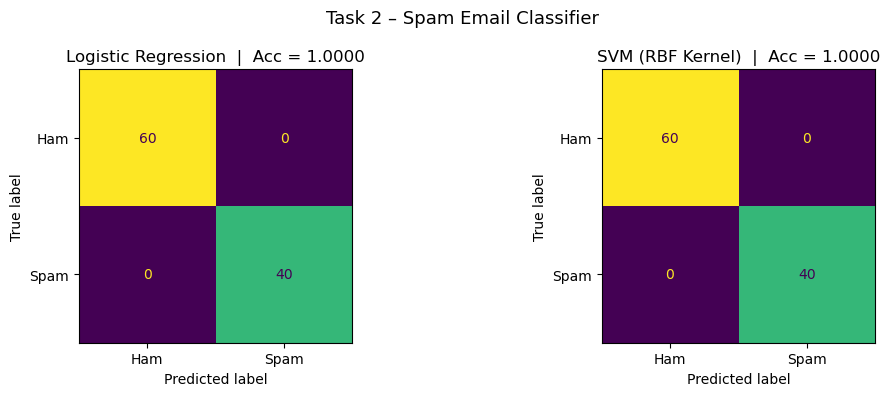

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(
    axes,
    [y2_lr, y2_svm],
    ['Logistic Regression', 'SVM (RBF Kernel)']
):
    ConfusionMatrixDisplay(confusion_matrix(y2_test, preds),
                           display_labels=['Ham','Spam']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{title}  |  Acc = {accuracy_score(y2_test, preds):.4f}")

fig.suptitle('Task 2 – Spam Email Classifier', fontsize=13)
plt.tight_layout()
plt.show()


### 2.6 · Classify New Emails

In [32]:
new_emails = pd.DataFrame([
    {'word_freq_free': 0.9, 'word_freq_money': 0.7, 'word_freq_click': 0.8,
     'email_length': 120, 'num_hyperlinks': 10, 'suspicious_sender': 1},
    {'word_freq_free': 0.05,'word_freq_money': 0.02,'word_freq_click': 0.01,
     'email_length': 450, 'num_hyperlinks': 1,  'suspicious_sender': 0},
])
preds_new = svm2.predict(sc2.transform(new_emails))
labels_map = {0: 'Ham (Not Spam)', 1: 'SPAM'}
for i, p in enumerate(preds_new):
    print(f"Email {i+1}: {labels_map[p]}")


Email 1: SPAM
Email 2: Ham (Not Spam)


## Task 3 – Customer Value Classification (SVM + Decision Tree)

### 3.1 · Generate Dataset

In [33]:
np.random.seed(7)
hv_n, lv_n = 180, 220

hv = pd.DataFrame({
    'total_spending'     : np.random.uniform(5000, 20000, hv_n),
    'age'                : np.random.randint(25, 55, hv_n),
    'num_visits'         : np.random.randint(10, 50, hv_n),
    'purchase_frequency' : np.random.uniform(0.5, 1.0, hv_n),
    'label': 1
})
lv = pd.DataFrame({
    'total_spending'     : np.random.uniform(100, 4999, lv_n),
    'age'                : np.random.randint(18, 70, lv_n),
    'num_visits'         : np.random.randint(1, 9, lv_n),
    'purchase_frequency' : np.random.uniform(0.0, 0.49, lv_n),
    'label': 0
})
df3 = pd.concat([hv, lv], ignore_index=True).sample(frac=1, random_state=3).reset_index(drop=True)
print(f"Shape: {df3.shape}")
print(f"Class balance:\n{df3['label'].value_counts().rename({0:'Low-Value',1:'High-Value'}).to_string()}")
df3.head(6)


Shape: (400, 5)
Class balance:
label
Low-Value     220
High-Value    180


,total_spending,age,num_visits,purchase_frequency,label
0,1659.837926,41,3,0.482413,0
1,8200.780304,47,14,0.684179,1
2,601.754271,28,4,0.304702,0
3,11721.809863,45,48,0.989759,1
4,16407.726800,26,12,0.764111,1
5,1976.713844,55,6,0.287626,0


### 3.2 · Clean, Clip Outliers & Scale

In [34]:
numeric3 = ['total_spending', 'age', 'num_visits', 'purchase_frequency']

for col in numeric3:
    Q1, Q3 = df3[col].quantile(0.25), df3[col].quantile(0.75)
    df3[col] = df3[col].clip(Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1))

X3 = df3[numeric3]
y3 = df3['label']
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.25, random_state=42, stratify=y3
)
sc3 = StandardScaler()
X3_tr_sc = sc3.fit_transform(X3_train)
X3_te_sc = sc3.transform(X3_test)
print(f"Train: {X3_tr_sc.shape}  |  Test: {X3_te_sc.shape}")


Train: (300, 4)  |  Test: (100, 4)


### 3.3 · SVM – Separating Hyperplane

In [35]:
from sklearn.svm import SVC

svm3 = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm3.fit(X3_tr_sc, y3_train)
y3_svm = svm3.predict(X3_te_sc)

print(f"SVM Accuracy: {accuracy_score(y3_test, y3_svm):.4f}\n")
print(classification_report(y3_test, y3_svm, target_names=['Low-Value','High-Value']))


SVM Accuracy: 0.9900

              precision    recall  f1-score   support

   Low-Value       0.98      1.00      0.99        55
  High-Value       1.00      0.98      0.99        45

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



### 3.4 · Decision Tree – Classification Rules

In [36]:
from sklearn.tree import DecisionTreeClassifier, export_text

dt3 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt3.fit(X3_train, y3_train)
y3_dt = dt3.predict(X3_test)

print(f"Decision Tree Accuracy: {accuracy_score(y3_test, y3_dt):.4f}\n")
print(classification_report(y3_test, y3_dt, target_names=['Low-Value','High-Value']))
print("\n--- Decision Rules ---")
print(export_text(dt3, feature_names=numeric3))


Decision Tree Accuracy: 1.0000

              precision    recall  f1-score   support

   Low-Value       1.00      1.00      1.00        55
  High-Value       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


--- Decision Rules ---
|--- total_spending <= 4981.33
|   |--- class: 0
|--- total_spending >  4981.33
|   |--- class: 1



### 3.5 · Confusion Matrices

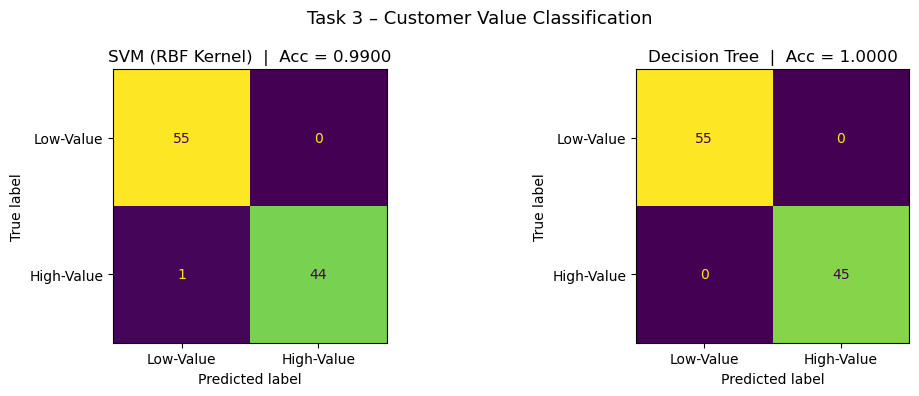

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, title in zip(
    axes,
    [y3_svm, y3_dt],
    ['SVM (RBF Kernel)', 'Decision Tree']
):
    ConfusionMatrixDisplay(confusion_matrix(y3_test, preds),
                           display_labels=['Low-Value','High-Value']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{title}  |  Acc = {accuracy_score(y3_test, preds):.4f}")

fig.suptitle('Task 3 – Customer Value Classification', fontsize=13)
plt.tight_layout()
plt.show()


### 3.6 · Scatter Visualisation (Spending vs Purchase Frequency)

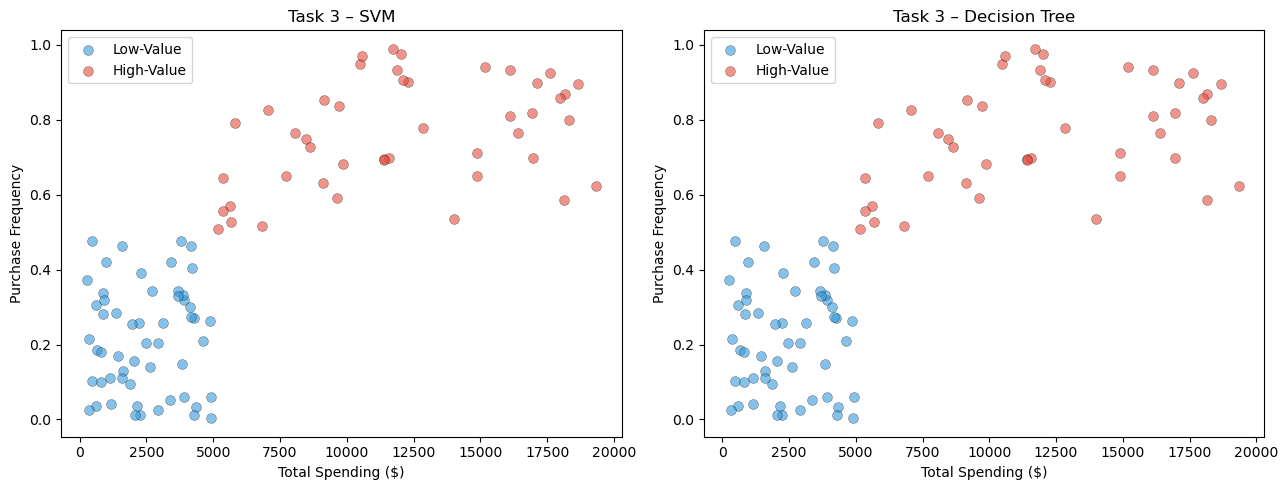

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in zip(
    axes, [y3_svm, y3_dt], ['SVM', 'Decision Tree']
):
    for cls, color, lbl in [(0,'#3498db','Low-Value'),(1,'#e74c3c','High-Value')]:
        mask = (y3_test == cls).values
        ax.scatter(
            X3_test.loc[y3_test.index[mask], 'total_spending'],
            X3_test.loc[y3_test.index[mask], 'purchase_frequency'],
            c=color, alpha=0.6, edgecolors='k', linewidths=0.3, label=lbl, s=50
        )
    ax.set_xlabel('Total Spending ($)')
    ax.set_ylabel('Purchase Frequency')
    ax.set_title(f'Task 3 – {title}')
    ax.legend()

plt.tight_layout()
plt.show()
